# Figure6_5

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure6")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from functions.sensitivity import load_human_fits, load_monkey_fits
from functions.plotting import set_paper_theme

set_paper_theme(tick_width=0.3, unicode_minus=False)


In [3]:
task_label = [
    "Animate vs. Inanimate",
    "Natural vs. Artificial",
    "Maml. vs. Nonmaml.",
    "Monkey vs. Mammal",
    "Human vs. Monkey",
    "Tools vs. Electronics",
]
task_list = [
    "animate_vs_inanimate",
    "natural_vs_artificial", 
    "mammal_vs_reptile", 
    "monkey_vs_mammal",
    "human_vs_monkey",
    "electronics_vs_tools"    
    ]

subj_list = [
    ["012","014","041","042","043","044","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
    ["012","013","017","041","042","043","072"],
]

### Simple correct-sign correlation (simplified structure)

In [4]:
corr_simple_mm = np.zeros(len(task_list))
corr_simple_hh = np.zeros(len(task_list))
corr_simple_mh = np.zeros(len(task_list))

for (n,task) in enumerate(task_list):
    uimg_monkey,k_monkey = load_monkey_fits(task)
    uimg_human,k_human = load_human_fits(task,subj_list[n])

    km = np.array(k_monkey)                        # (3, n_img)
    kh = np.array(k_human)                         # (n_human, n_img)
    n_m = km.shape[0]
    n_h = kh.shape[0]

    # monkey-monkey: mean over all pairs of single-subject k vectors (C(3,2) pairs)
    Cm = np.corrcoef(km)
    corr_simple_mm[n] = np.mean(Cm[np.triu_indices(n_m, k=1)])

    # human-human: mean over all pairs of single-subject k vectors (C(7,2) pairs)
    Ch = np.corrcoef(kh)
    corr_simple_hh[n] = np.mean(Ch[np.triu_indices(n_h, k=1)])

    # monkey-human: mean over all monkey-human single-subject pairs (3 x 7 pairs)
    # (all pairwise Pearson correlations between the monkey and human k vectors)
    Cmh = np.corrcoef(km, kh)[:n_m, n_m:]          # (n_m, n_h) cross block
    corr_simple_mh[n] = np.mean(Cmh)

print("per-task  MM (3 pairs):", np.round(corr_simple_mm, 3))
print("per-task  HH (21 pairs):", np.round(corr_simple_hh, 3))
print("per-task  MH (21 pairs):", np.round(corr_simple_mh, 3))
print("mean  MM: %.4f (SE: %.4f)  HH: %.4f (SE: %.4f)  MH: %.4f (SE: %.4f)"%(
    corr_simple_mm.mean(), corr_simple_mm.std(ddof=1)/np.sqrt(6),
    corr_simple_hh.mean(), corr_simple_hh.std(ddof=1)/np.sqrt(6),
    corr_simple_mh.mean(), corr_simple_mh.std(ddof=1)/np.sqrt(6)
))

per-task  MM (3 pairs): [0.227 0.298 0.383 0.407 0.478 0.213]
per-task  HH (21 pairs): [0.207 0.319 0.234 0.339 0.249 0.465]
per-task  MH (21 pairs): [0.136 0.186 0.122 0.159 0.232 0.195]
mean  MM: 0.3343 (SE: 0.0432)  HH: 0.3020 (SE: 0.0386)  MH: 0.1718 (SE: 0.0165)


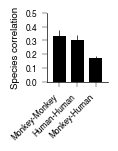

In [5]:
# Plot simple correct-sign correlations (vertical bars)
fig, ax = plt.subplots()
# height 105 so the two-line ylabel fits with the rotated xticklabels below
fig.set(figheight=105/75, figwidth=80/75)

simple_mean = np.array([corr_simple_mm.mean(), corr_simple_hh.mean(), corr_simple_mh.mean()])
simple_se = np.array([corr_simple_mm.std(ddof=1)/np.sqrt(len(corr_simple_mm)),
                      corr_simple_hh.std(ddof=1)/np.sqrt(len(corr_simple_hh)),
                      corr_simple_mh.std(ddof=1)/np.sqrt(len(corr_simple_mh))])
simple_label = ["Monkey-Monkey", "Human-Human", "Monkey-Human"]

ax.bar(range(3), simple_mean, width=0.7, color="black", yerr=simple_se, error_kw={"linewidth":0.5})
ax.set_xticks(range(3), simple_label, rotation=45, ha="right")
ax.set_xlim([-0.7, 2.7])
ax.set_ylim([0, 0.5])
ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax.set_ylabel("Species correlation")
plt.savefig(FIGURE_OUTPUT_DIR / f"sensitivity_correlation_between_individuals.pdf", bbox_inches="tight")
plt.show()